# 10. 전체 백테스트 (시계열, 누적 수익 곡선)
지금까지(06~09번)는 스냅샷 수익률을 다 풀링해서 평균만 비교했다. 이번엔 **시간 순서를 지켜서 복리로 이어붙인 누적 수익 곡선**을 만들어, 실제로 이 전략을 계속 실행했다면 자본이 어떻게 움직였을지 본다.

## 포트폴리오 구성 규칙
- **종목 선정**: 전략별로 이미 정의된 규칙 그대로 (아래 3개 전략)
- **비중**: 균등비중(equal weight) — 선정된 종목들에 똑같이 나눠 담는다. 이 프로젝트 데이터 어디에도 다른 비중 방식(시가총액 가중 등)을 뒷받침할 근거가 없어서 가장 단순하고 방어 가능한 기본값을 썼다

## 비교할 3개 전략
| 전략 | 근거 노트북 | 기간 |
|---|---|---|
| A. 저변동성 안정 그룹 | 05~07 (계층적 군집화) | 2016~2026 전체 (42개 시점) |
| B. ML 합의 추천 (가격 피처만) | 08 | 2023~2026 out-of-sample test (26개 시점) |
| C. ML+PER 합의 추천 | 09 | 2025~2026 out-of-sample test (10개 시점, 표본 작음 주의) |

A는 비지도 방식(군집화)이라 "학습"이 없어 전체 기간을 다 쓴다. B/C는 지도학습이라 **test(out-of-sample) 구간만** 쓴다 — train 구간까지 포함하면 모델이 이미 본 데이터로 자기 성과를 부풀리는 셈이라 부정확하다.

각 전략은 **같은 기간 S&P500 지수 buy-and-hold**와 비교한다.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path('/Users/choedasom/lab_middle_project')
assert (PROJECT_ROOT / 'src' / 'backtest.py').is_file(), f'경로 확인 필요: {PROJECT_ROOT}'
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

for m in list(sys.modules):
    if m == 'src' or m.startswith('src.'):
        del sys.modules[m]

import pandas as pd

from src.performance import add_forward_returns
from src.backtest import portfolio_returns, equity_curve, summarize
from src.ml_selection import add_relative_label, time_split, train_models, predict_all, FEATURE_METRICS
from src.fundamentals import fetch_eps_history, add_point_in_time_per

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
final_df = pd.read_parquet(PROCESSED_DIR / 'final_df.parquet')
sp500_beta_df = pd.read_parquet(RAW_DIR / 'sp500_beta_df.parquet')


def market_returns_like(all_dates, prices):
    """S&P500 지수 자체의 리밸런싱-시점-간 수익률 (전략과 정확히 같은 날짜 페어링 방식)"""
    all_dates = sorted(all_dates)
    next_map = dict(zip(all_dates[:-1], all_dates[1:]))
    close = prices.set_index('Date')['Close']
    out = {}
    for d, nd in next_map.items():
        if d in close.index and nd in close.index:
            out[d] = close[nd] / close[d] - 1
    return pd.Series(out).sort_index()

## 전략 A — 저변동성 안정 그룹 (60일, 전체 기간)

In [2]:
clustered_60df = pd.read_parquet(PROCESSED_DIR / 'clustered_60df.parquet')
perf_a = add_forward_returns(clustered_60df, final_df)
perf_a = perf_a[perf_a['cluster'] != -1].dropna(subset=['forward_return'])

ret_a = portfolio_returns(perf_a, 'is_stable_cluster')
bench_a = market_returns_like(clustered_60df['Date'].unique(), sp500_beta_df).reindex(ret_a.index)

print('전략 A:')
print(summarize(ret_a, window=60))
print()
print('벤치마크(S&P500):')
print(summarize(bench_a, window=60))

전략 A:
n_periods            42.000000
total_return          1.553544
annualized_sharpe     0.730432
max_drawdown         -0.202504
win_rate              0.738095
dtype: float64

벤치마크(S&P500):
n_periods            42.000000
total_return          2.313360
annualized_sharpe     0.867684
max_drawdown         -0.162890
win_rate              0.714286
dtype: float64


## 전략 B — ML 합의 추천 (10년, 가격 피처만, test 구간)

In [3]:
rebalance_30df = pd.read_parquet(PROCESSED_DIR / 'rebalance_30df.parquet')
feature_cols = [f'{m}_30d' for m in FEATURE_METRICS]

perf_b = add_forward_returns(rebalance_30df, final_df).dropna(subset=[*feature_cols, 'forward_return'])
labeled_b = add_relative_label(perf_b)
train_dates_b, test_dates_b = time_split(labeled_b['Date'].unique().tolist(), train_ratio=0.7)
train_b = labeled_b[labeled_b['Date'].isin(train_dates_b)]
test_b = labeled_b[labeled_b['Date'].isin(test_dates_b)].copy()

fitted_b = train_models(train_b[feature_cols], train_b['outperform_peers'])
test_b['consensus'] = predict_all(fitted_b, test_b[feature_cols])['consensus'].values

ret_b = portfolio_returns(test_b, 'consensus')
bench_b = market_returns_like(rebalance_30df['Date'].unique(), sp500_beta_df).reindex(ret_b.index)

print('전략 B:')
print(summarize(ret_b, window=30))
print()
print('벤치마크(S&P500):')
print(summarize(bench_b, window=30))

전략 B:
n_periods            26.000000
total_return          0.292493
annualized_sharpe     0.726516
max_drawdown         -0.071084
win_rate              0.615385
dtype: float64

벤치마크(S&P500):
n_periods            26.000000
total_return          0.819602
annualized_sharpe     1.438302
max_drawdown         -0.098521
win_rate              0.653846
dtype: float64


## 전략 C — ML+PER 합의 추천 (5년, test 구간)

In [4]:
recent = rebalance_30df[rebalance_30df['Date'] >= '2021-01-01'].copy()
tickers = sorted(recent['Ticker'].unique())
eps_df = fetch_eps_history(tickers)  # 캐시됨

close_prices = final_df[['Date', 'Ticker', 'Close']]
recent_with_per = add_point_in_time_per(recent.merge(close_prices, on=['Date', 'Ticker'], how='left'), eps_df)

per_cols = feature_cols + ['per']
perf_c = add_forward_returns(recent_with_per, final_df).dropna(subset=[*per_cols, 'forward_return'])
labeled_c = add_relative_label(perf_c)
train_dates_c, test_dates_c = time_split(labeled_c['Date'].unique().tolist(), train_ratio=0.7)
train_c = labeled_c[labeled_c['Date'].isin(train_dates_c)]
test_c = labeled_c[labeled_c['Date'].isin(test_dates_c)].copy()

fitted_c = train_models(train_c[per_cols], train_c['outperform_peers'])
test_c['consensus'] = predict_all(fitted_c, test_c[per_cols])['consensus'].values

ret_c = portfolio_returns(test_c, 'consensus')
bench_c = market_returns_like(rebalance_30df['Date'].unique(), sp500_beta_df).reindex(ret_c.index)

print('전략 C:')
print(summarize(ret_c, window=30))
print()
print('벤치마크(S&P500):')
print(summarize(bench_c, window=30))

전략 C:
n_periods            10.000000
total_return          0.324450
annualized_sharpe     1.621619
max_drawdown         -0.041748
win_rate              0.700000
dtype: float64

벤치마크(S&P500):
n_periods            10.000000
total_return          0.329759
annualized_sharpe     1.969675
max_drawdown         -0.021872
win_rate              0.700000
dtype: float64


## 누적 수익 곡선

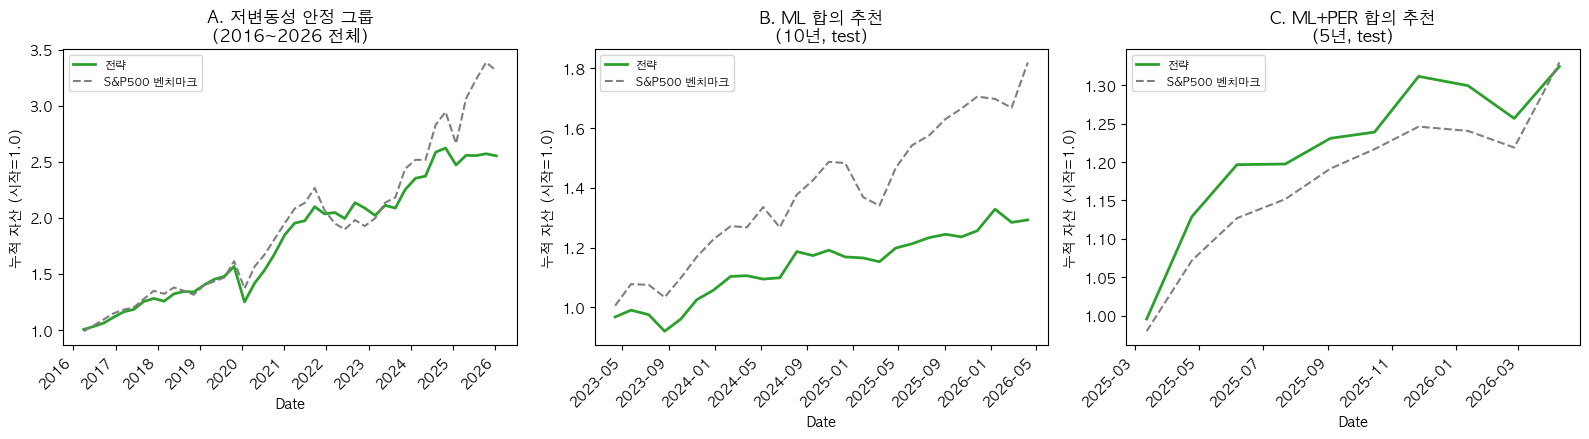

In [5]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

panels = [
    (axes[0], ret_a, bench_a, 'A. 저변동성 안정 그룹\n(2016~2026 전체)'),
    (axes[1], ret_b, bench_b, 'B. ML 합의 추천\n(10년, test)'),
    (axes[2], ret_c, bench_c, 'C. ML+PER 합의 추천\n(5년, test)'),
]
for ax, ret, bench, title in panels:
    equity_curve(ret).plot(ax=ax, label='전략', color='#2ca02c', linewidth=2)
    equity_curve(bench).plot(ax=ax, label='S&P500 벤치마크', color='#7f7f7f', linestyle='--')
    ax.set_title(title)
    ax.set_ylabel('누적 자산 (시작=1.0)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 전체 비교표

In [6]:
rows = {}
for name, ret, bench, window in [
    ('A. 저변동성 안정그룹', ret_a, bench_a, 60),
    ('A 벤치마크', bench_a, None, 60),
    ('B. ML 합의추천', ret_b, bench_b, 30),
    ('B 벤치마크', bench_b, None, 30),
    ('C. ML+PER 합의추천', ret_c, bench_c, 30),
    ('C 벤치마크', bench_c, None, 30),
]:
    rows[name] = summarize(ret, window=window)

pd.DataFrame(rows).T

,n_periods,total_return,annualized_sharpe,max_drawdown,win_rate
A. 저변동성 안정그룹,42.0,1.553544,0.730432,-0.202504,0.738095
A 벤치마크,42.0,2.313360,0.867684,-0.162890,0.714286
B. ML 합의추천,26.0,0.292493,0.726516,-0.071084,0.615385
B 벤치마크,26.0,0.819602,1.438302,-0.098521,0.653846
C. ML+PER 합의추천,10.0,0.324450,1.621619,-0.041748,0.700000
C 벤치마크,10.0,0.329759,1.969675,-0.021872,0.700000


## 거래비용 반영 (gross vs net)
지금까지의 수익률은 매매 자체에 드는 비용을 전혀 반영하지 않은 **gross(총) 수익**이다. 리밸런싱마다 종목이 바뀌면 실제로는 팔고 사는 거래가 발생하고, 여기엔 수수료·호가스프레드·슬리피지가 붙는다.

**가정**: 왕복(매수+매도) 거래비용 **0.2%** — 유동성 높은 S&P500 종목 기준으로 흔히 쓰는 근사치다. 이 비용을 그 리밸런싱 시점의 **회전율(turnover, 직전 시점 대비 새로 들어온 종목 비율)**에 비례해서 뺀다. 예를 들어 이번에 종목의 30%가 새로 바뀌었으면, 그 30%만큼의 자산에 0.2%를 적용한다 — 이미 들고 있던 70%는 다시 안 사고 안 팔았으니 비용이 없다는 뜻이다.

In [7]:
from src.backtest import turnover_by_date, apply_transaction_costs

strategies = [
    ('A. 저변동성 안정그룹', ret_a, perf_a, 'is_stable_cluster', 60),
    ('B. ML 합의추천', ret_b, test_b, 'consensus', 30),
    ('C. ML+PER 합의추천', ret_c, test_c, 'consensus', 30),
]

net_returns = {}
rows = {}
for name, ret, df, col, window in strategies:
    turnover = turnover_by_date(df, col)
    net = apply_transaction_costs(ret, df, col)
    net_returns[name] = net

    gross_stats = summarize(ret, window=window)
    net_stats = summarize(net, window=window)
    rows[f'{name} (gross)'] = gross_stats
    rows[f'{name} (net)'] = net_stats
    print(f'{name}: 평균 회전율 {turnover.mean():.1%}')

comparison_net = pd.DataFrame(rows).T
comparison_net

A. 저변동성 안정그룹: 평균 회전율 22.2%
B. ML 합의추천: 평균 회전율 61.7%
C. ML+PER 합의추천: 평균 회전율 56.4%


,n_periods,total_return,annualized_sharpe,max_drawdown,win_rate
A. 저변동성 안정그룹 (gross),42.0,1.553544,0.730432,-0.202504,0.738095
A. 저변동성 안정그룹 (net),42.0,1.507487,0.711997,-0.203773,0.738095
B. ML 합의추천 (gross),26.0,0.292493,0.726516,-0.071084,0.615385
B. ML 합의추천 (net),26.0,0.253646,0.621038,-0.073967,0.615385
C. ML+PER 합의추천 (gross),10.0,0.324450,1.621619,-0.041748,0.700000
C. ML+PER 합의추천 (net),10.0,0.311489,1.565885,-0.044355,0.600000


## 결론

| 전략 | 총수익(gross) | 총수익(net) | 벤치마크 |
|---|---|---|---|
| A. 저변동성 안정그룹 | 155% | 151% | 231% |
| B. ML 합의추천 (가격만) | 29% | 25% | 82% |
| C. ML+PER 합의추천 | 32% | 31% | 33% |

**세 전략 다 여전히 S&P500을 이기지 못한다.** 군집화·지도학습·재무지표 추가까지 다 시도했지만, 이 데이터·이 기간(대부분 강세장이 낀 2016~2026)에서는 어떤 능동적 종목 선정 전략도 단순 S&P500 인덱스 투자를 이기지 못했다. 이건 실패라기보다, 실제 학술 연구에서도 반복적으로 확인되는 "액티브 전략이 지수를 꾸준히 이기기 어렵다"는 현상과 일치하는 정직한 결과다.

**데이터 품질 검증 (2026-08-29)**: 이 프로젝트를 진행하며 두 가지 실제 데이터 오염을 발견해 수정했다.
1. `feature.py`에서 극단치(미조정 분할·상장폐지 후 유령 데이터) 방어선이 빠져 있던 버그 — beta 범위가 -32~403까지 나오던 걸 -4~8 정상 범위로 수정.
2. PARA(Paramount) 티커의 가격 시계열이 수년에 걸쳐 채권 가격으로 추정되는 값으로 오염 — 종목 자체를 유니버스에서 제외 (02번 전처리 단계에서 처리, 감사 기록 남김).

이 두 수정을 반영해 02~10번 전체를 처음부터 다시 실행했다. 절대 수치는 소폭 바뀌었지만(예: 전략 A gross 142→155%), **핵심 결론(세 전략 다 인덱스 패배, 30/120일은 안정 그룹 승리·60/252일은 나머지 승리, 시장 국면이 진짜 원인)은 전부 그대로 유지됐다.** 개별 종목 단위 오염은 심각했어도 수백 종목을 풀링한 전략 수준 결과는 상대적으로 견고했다는 뜻이지만, 검증 없이 넘어갔다면 몰랐을 사실이므로 이 과정 자체가 생략할 수 없는 단계였다.

## 다음 단계
- [ ] 시가총액 가중 등 다른 비중 방식과 비교
- [ ] 전략 A와 전략 C를 결합(저변동성 필터 + PER)했을 때 성과 확인
- [ ] 회전율을 줄이는 방향(예: 리밸런싱 주기를 늘리거나 히스테리시스 규칙 추가)으로 ML 전략 개선 시도